# 导入库

In [77]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import os
from torchvision.datasets import ImageFolder
from torchvision.transforms import ToTensor
from torchvision.utils import make_grid
from torch.utils.data.dataloader import DataLoader
from torch.utils.data import random_split
import torch.nn.functional as F
from tqdm import tqdm

# os.environ解决部分系统上的库冲突的问题，例如macOS
# os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# 检查设备
并编写自动化将数据集迁移至GPU上

In [78]:
# 判断并打印出默认使用的GPU还是CPU训练，并保存到device的变量中以便使用
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda:0


In [79]:

def to_device(
        data:torch.Tensor,
        device:torch.device
    ) -> torch.Tensor:
    """ 
    将数据移动到GPU上进行训练，对所有数据递归处理，返回列表，再进行数据迁移至GPU/CPU
    """
    if isinstance(data, (list,tuple)):
        return [to_device(x, device) for x in data] 
    return data.to(device, non_blocking=True)
 
class DeviceDataLoader():
    """自动化将数据集移动到GPU/CPU上"""
    def __init__(self, dl, device):
        self.dl = dl
        self.device = device
        
    def __iter__(self):
        """迭代器，迭代时生成已移动到设备的数据批次"""
        for b in self.dl: 
            yield to_device(b, self.device)
 
    def __len__(self):
        """返回批次数量"""
        return len(self.dl)

# 导入数据集

In [80]:
# 导入图像数据，使用ImageFolder将图像转为Pytorch所识别能识别的tensor
train = ImageFolder("./fruits-360/Training", transform=ToTensor())
test = ImageFolder("./fruits-360/Test", transform=ToTensor())
img, label = train[0]
print(img.shape, label)
img

torch.Size([3, 100, 100]) 0


tensor([[[0.9961, 0.9961, 0.9961,  ..., 1.0000, 1.0000, 1.0000],
         [0.9961, 0.9961, 0.9961,  ..., 1.0000, 1.0000, 1.0000],
         [0.9961, 0.9961, 0.9961,  ..., 1.0000, 1.0000, 1.0000],
         ...,
         [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000]],

        [[1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
         ...,
         [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000]],

        [[1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.

Label:Apple Braeburn, (0)


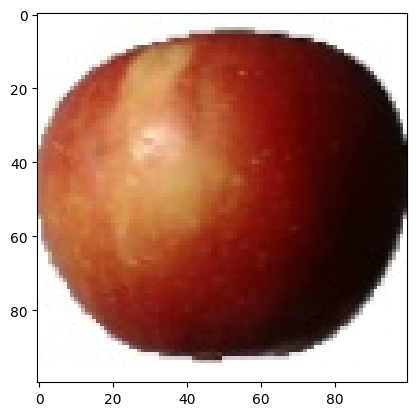

In [81]:
# 从(C, H, W)转为Pytorch(H, W, C)，其中C是通道数：RGB，H是高，W是宽
print(f"Label:{train.classes[label]}, ({str(label)})")
plt.imshow(img.permute(1, 2, 0))
plt.show()

# 对数据集进行划分

In [82]:
# 设置随机种子保证可重现性
torch.manual_seed(20) 

# 切分20%的训练集为验证集
val_size = round(len(train) * 0.2)
train_size = round(len(train) - val_size)

#随机划分
train_ds, val_ds = random_split(train, [train_size, val_size])
print(len(train_ds))
print(len(val_ds))

54154
13538


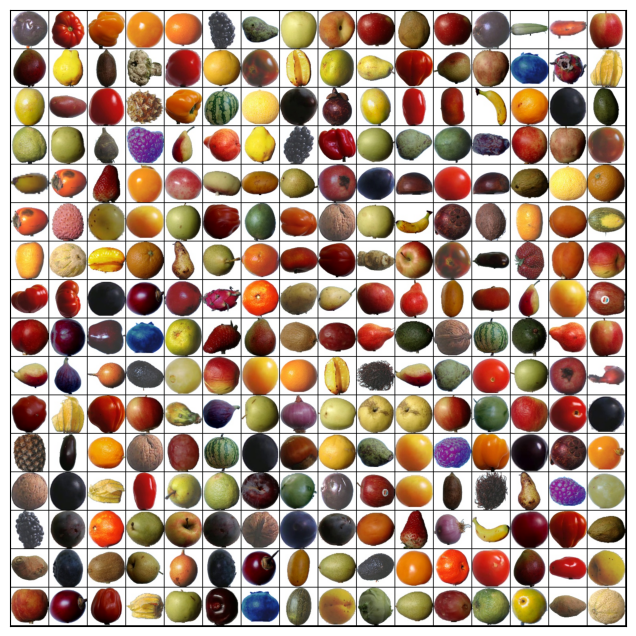

In [83]:
# 划分训练规模
batch_size = 256
train_dl = DataLoader(train_ds, batch_size, shuffle=True, pin_memory=True) # shuffle设置为True以开启打乱数据集，pin_memory设置为True以在GPU显存上划分出一块内存存储数据
val_dl = DataLoader(val_ds, batch_size * 2, pin_memory=True)

# 可视化
for img, label in train_dl:
    i, j = plt.subplots(figsize=(12, 8))
    j.set_xticks([])
    j.set_yticks([])
    j.imshow(make_grid(img, nrow=16).permute(1, 2, 0))
    break
plt.show()

# 准确率计算函数

In [84]:
def accuracy(outputs, labels):
    """计算准确率"""
    _, preds = torch.max(outputs, dim=1)
    return torch.tensor(torch.sum(preds == labels).item() / len(preds))

# 创建图形基类

In [85]:
class ImageBase(nn.Module):
    """图像分类模型基类"""
    def training_step(self, batch):
        """训练步骤"""
        images, labels = batch 
        out = self(images)                      # 生成预测
        loss = F.cross_entropy(out, labels)     # 计算损失
        return loss
    
    def validation_step(self, batch):
        """验证步骤"""
        images, labels = batch 
        out = self(images)                      # 生成预测
        loss = F.cross_entropy(out, labels)     # 计算损失
        acc = accuracy(out, labels)             # 计算损失率
        return {'val_loss': loss.detach(), 'val_acc': acc}
        
    def validation_epoch_end(self, outputs):
        """验证周期结束处理"""
        batch_losses = [x['val_loss'] for x in outputs]
        epoch_loss = torch.stack(batch_losses).mean()   # 合并损失率
        batch_accs = [x['val_acc'] for x in outputs]
        epoch_acc = torch.stack(batch_accs).mean()      # 合并准确率
        return {'val_loss': epoch_loss.item(), 'val_acc': epoch_acc.item()}
    
    def epoch_end(self, epoch, result):
        """每周期训练信息进行打印输出"""
        print(f"Epoch [{epoch}], train_loss: {result["train_loss"]:.4f}, val_loss: {result["val_loss"]:.4f}, val_acc: {result["val_acc"]:.4f}")

# 创建CNN模型（继承自图形基类）

In [86]:
class CnnModel(ImageBase):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential( # 神经网络框架？容器
            nn.Conv2d(3, 16, kernel_size=2, padding=1), 
            nn.BatchNorm2d(16), # 对16个输出进行归一化
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # 池化100x100 -> 50x50 最终输出为：16x50x50
 
            nn.Conv2d(16, 32, kernel_size=2, stride=1, padding=1), 
            nn.BatchNorm2d(32), # 对32个输出进行归一化
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # 池化50x50 -> 25x25 最终输出为：32x25x25
 
            nn.Conv2d(32, 64, kernel_size=2, stride=1, padding=1),
            nn.BatchNorm2d(64), # 对64个输出进行归一化
            nn.ReLU(),
            nn.MaxPool2d(5, 5), # 池化25x25 -> 5x5 最终输出为：64x5x5
 
            nn.Flatten(),       # 展平为向量
            nn.Dropout(0.3),    # 丢弃30%的神经元防止过拟合
            nn.ReLU(),
            nn.Linear(64*5*5, 131) # 全连接层
        )
        
    def forward(self, xb):
      """向前传播"""
      return self.network(xb)
 
model = CnnModel()
model

CnnModel(
  (network): Sequential(
    (0): Conv2d(3, 16, kernel_size=(2, 2), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(2, 2), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(2, 2), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=5, stride=5, padding=0, dilation=1, ceil_mode=False)
    (12): Flatten(start_dim=1, end_dim=-1)
    (13): Dropout(p=0.3, inplace=False)
    (14): ReLU()
    (15): Linear(in_features=1600, out_features=131, bias=True)
  )
)

# 编写训练以及评估函数
并将模型迁移至GPU上

In [87]:
@torch.no_grad()                                                            # 关闭梯度计算
def evaluate(model, val_loader):
    """评估模型在验证集上的性能"""
    model.eval() # 将模型切换为评估模式
    outputs = [model.validation_step(batch) for batch in val_loader]
    return model.validation_epoch_end(outputs)
 
def get_lr(optimizer):
    """获取当前学习率"""
    for param_group in optimizer.param_groups:
        return param_group['lr']
 
def fit_one_cycle(
        epochs,                  # 周期
        max_lr,                  # 学习率
        model,                   # 模型
        train_loader,            # 训练集
        val_loader,              # 测试集
        weight_decay=0,          # 默认权重为0
        grad_clip=None,          # 默认梯度衰减为0
        opt_func=torch.optim.SGD # 默认调用随机梯度，以防调用Adam错误
    ):
    """单周期学习率调度函数"""

    torch.cuda.empty_cache()                                                # 清理GPU缓存
    history = []                                                            # 保存历史
    
    optimizer = opt_func(model.parameters(), max_lr, weight_decay=weight_decay)
    
    # 设置单周期学习率调度器
    sched = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, 
        max_lr, 
        epochs=epochs,
        steps_per_epoch=len(train_loader)
        )
    
    # 训练阶段
    for epoch in range(epochs):
        model.train()       # 将模型设置为训练模式
        train_losses = []   # 记录损失
        lrs = []            # 记录学习率变化

        # 可视化进度条进行批次训练
        for batch in tqdm(train_loader):
            loss = model.training_step(batch)
            train_losses.append(loss)
            loss.backward()     # 反向传播
            
            # 梯度裁剪，防止梯度爆炸
            if grad_clip: 
                nn.utils.clip_grad_value_(model.parameters(), grad_clip)
            
            optimizer.step()        # 更新权重
            optimizer.zero_grad()   # 清除梯度
            
            lrs.append(get_lr(optimizer))   # 记录学习率
            sched.step()                    # 更新学习率
        
        # 对模型进行验证
        result = evaluate(model, val_loader)
        result['train_loss'] = torch.stack(train_losses).mean().item()
        result['lrs'] = lrs
        model.epoch_end(epoch, result)
        history.append(result)
    return history
 
 
model = to_device(model, device)
model

CnnModel(
  (network): Sequential(
    (0): Conv2d(3, 16, kernel_size=(2, 2), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(2, 2), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(2, 2), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=5, stride=5, padding=0, dilation=1, ceil_mode=False)
    (12): Flatten(start_dim=1, end_dim=-1)
    (13): Dropout(p=0.3, inplace=False)
    (14): ReLU()
    (15): Linear(in_features=1600, out_features=131, bias=True)
  )
)

# 迁移数据集至GPU上

In [88]:
# 迁移数据集到GPU/CPU上
train_dl = DeviceDataLoader(train_dl, device)
valid_dl = DeviceDataLoader(val_dl, device)

# 预测函数

In [89]:
def predict_image(
        img:torch.Tensor,
        model:torch.nn.Module
    ) -> str: 
    """
    传入图像张量，以及要使用的模型，模型将会把数据迁移至GPU上进行预测，
    并返回字符类型131类水果中的一类
    """
    xb = to_device(img.unsqueeze(0), device)
    yb = model(xb)
    _, preds  = torch.max(yb, dim=1)
    return train.classes[preds[0].item()]

# 评估模型

In [90]:
history = [evaluate(model, valid_dl)]
history

[{'val_loss': 4.876694202423096, 'val_acc': 0.014616750180721283}]

# 训练配置

In [91]:
epochs = 4                  # 训练次数（周期）
max_lr = 0.01               # 最大学习率
grad_clip = 0.1             # 梯度裁剪（防止梯度爆炸）
weight_decay = 0.001        # 权重衰减
opt_func = torch.optim.Adam # 启用Adam优化器

# 训练模型

In [92]:
history += fit_one_cycle(
    epochs, 
    max_lr, 
    model,
    train_dl, 
    valid_dl, 
    grad_clip=grad_clip, 
    weight_decay=weight_decay, 
    opt_func=opt_func
    )
history

100%|██████████| 212/212 [00:19<00:00, 11.12it/s]


Epoch [0], train_loss: 0.8533, val_loss: 0.6092, val_acc: 0.8503


100%|██████████| 212/212 [00:18<00:00, 11.40it/s]


Epoch [1], train_loss: 0.0510, val_loss: 0.0027, val_acc: 0.9995


100%|██████████| 212/212 [00:18<00:00, 11.27it/s]


Epoch [2], train_loss: 0.0049, val_loss: 0.0003, val_acc: 0.9999


100%|██████████| 212/212 [00:18<00:00, 11.26it/s]


Epoch [3], train_loss: 0.0014, val_loss: 0.0002, val_acc: 0.9999


[{'val_loss': 4.876694202423096, 'val_acc': 0.014616750180721283},
 {'val_loss': 0.609248697757721,
  'val_acc': 0.8502777218818665,
  'train_loss': 0.8533313870429993,
  'lrs': [0.0003999999999999993,
   0.0004003688860255636,
   0.0004014754874035482,
   0.00040331963404654364,
   0.0004059010425045799,
   0.00040921931600869724,
   0.00041327394453192536,
   0.0004180643048676807,
   0.0004235896607255561,
   0.00042984916284447873,
   0.0004368418491232616,
   0.00044456664476846645,
   0.0004530223624596066,
   0.00046220770253164317,
   0.0004721212531747492,
   0.0004827614906513008,
   0.0004941267795300804,
   0.0005062153729376573,
   0.000519025412826871,
   0.0005325549302624324,
   0.0005468018457235393,
   0.0005617639694235205,
   0.0005774390016463973,
   0.0005938245331003622,
   0.0006109180452880912,
   0.0006287169108938478,
   0.0006472183941872989,
   0.0006664196514440147,
   0.0006863177313825436,
   0.0007069095756180432,
   0.0007281920191323579,
   0.00075016

# 手动对模型进行验证

Label: 		Apple Braeburn
Predicted:	Apple Braeburn


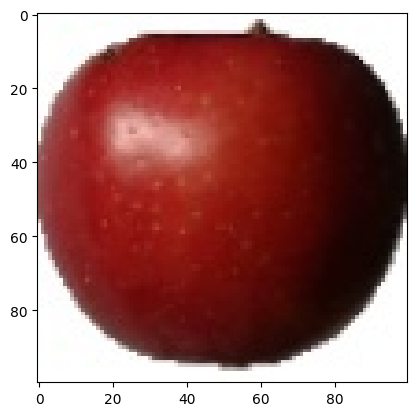

In [93]:
img, label = test[69]
plt.imshow(img.permute(1, 2, 0))
print(f"Label: \t\t{train.classes[label]}\nPredicted:\t{predict_image(img, model)}")

# 保存模型

In [94]:
torch.save(model, "cnn.pth")

# 可视化预测
### 对传入的图像进行处理预测

In [ ]:
import gradio as gr
from PIL import Image

# def show(img):
#     return img

# 加载模型，并切换为评估模式
model = torch.load("cnn.pth")
model.eval()

def predict(img):
    if isinstance(img, str):        # 判断传入的img是否为字符类型
        img_proc = Image.open(img)
    else:
        return "FileRequestError"
    img_proc = img_proc.resize((100, 100))  # 对图片进行强制缩放处理
    img_proc.save("./Temp/test/test.jpg")   # 保存到本地以便导入到模型预测
    img_md = ImageFolder("./Temp", transform=ToTensor())
    i, l = img_md[0]
    result = predict_image(i, model) # 调用预测函数
    return result


demo = gr.Interface(
    fn = predict,
    inputs = gr.Image(type="filepath"),
    title="水果识别分类器",
    outputs = gr.Text(type="text"),
    description="上传水果图像，模型将识别其种类（支持131种水果）"
)

# 启动graio服务器
demo.launch()